<div>
Olá, Fabrício!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor v1</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. Essa versão do seu trabalho ficou muito boa! Espero que as sugestões sejam relevantes para projetos futuros.
    
<br>
Te desejo uma jornada de muito sucesso e aprendizado.
    
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

# Análise de Corridas de Taxi

Data: 29/09/2024

Nome: Fabrício Camacho

## Objetivo
O presente projeto tem como objetivo entender a dinâmica das corridas de taxi am Chicago. Para tanto, temos os seguintes objetivos específicos:
- Identificar os 10 principais bairros em termos de destino e comprar os resultados entre eles;
- Identificar as 10 empresas que mais realizaram viagens de taxi e comparar o número de corridas de taxi para cada uma delas;
- Verificar se o número de corridas de taxi realizadas pela empresa Loop ao Aeroporto Internacional O'Hare aos sábados muda em períodos chuvosos.

## Verificação e preparação de dados

### Importando bibliotecas

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

### Importando os dados para observação

In [30]:
df_trips_amount = pd.read_csv('/datasets/project_sql_result_01.csv')
df_trips_amount.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [31]:
df_dropoff_data = pd.read_csv('/datasets/project_sql_result_04.csv')
df_dropoff_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [32]:
df_loop_airport = pd.read_csv('/datasets/project_sql_result_07.csv')
df_loop_airport.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os arquivos de dados foram carregados corretamente
- As bibliotecas foram carregadas corretamente e em uma célula separada
</div>

In [33]:
# Verificando formatos das colunas start_ts e duration_seconds:
df_loop_airport.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


É possível observar as seguintes informações:
- Aparentemente não há problemas de formatação nos dataframes "df_trips_amount" e "df_dropoff_data";
- A coluna "start_ts" do dataframe "df_loop_airport" está no formato object e precisa ser alterado para datetime;
- A coluna "duration_seconds" do dataframe "df_loop_airport" está no formato float e pode ser alterado para int.

### Correção de dados

In [34]:
# Convertendo a coluna "start_ts" para o tipo dataframe:
df_loop_airport['start_ts'] = pd.to_datetime(df_loop_airport['start_ts'], format='%Y-%m-%d %H:%M:%S')

# Convertendo a coluna "duration_seconds" para int:
df_loop_airport['duration_seconds'] = df_loop_airport['duration_seconds'].astype(int)

# Imprimindo informações para conferência:
df_loop_airport.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 25.2+ KB


<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O método `head()` foi  utilizado para exibir uma amostra inicial dos seus dados
- O método `info()` foi utilizado para estudo inicial do conjunto de dados
- **Sugestão:** você poderia executar os comandos acima para isolar a execução do código. Além disso, você poderia usar o método `.describe()` também para analisar as estatísticas descritivas dos dados

</div>

## Visualisando e Analisando dados
### Bairros mais visitados

Vamos verificar os bairros mais visitados em termos de destino. Para isso, vamos trabalhar com "df_dropoff_data", uma vez que o mesmo contém a média de viagens para cada bairro. Vamos ordenar as médias de viagens em novembro em ordem decrescente a visualizar somente os 10 primeiros bairros mais visitados no referido mês.

In [35]:
# Ordenando médias de viagens em ordem decrescente e criando um novo df contendo os 10 maiores valores.
top_neighbourhoods = df_dropoff_data.sort_values(by='average_trips', ascending=False).head(10)

# Imprimindo os 10 primeiros bairros mais visitados.
print('Os bairros mais visitados em média são:')
top_neighbourhoods


Os bairros mais visitados em média são:


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


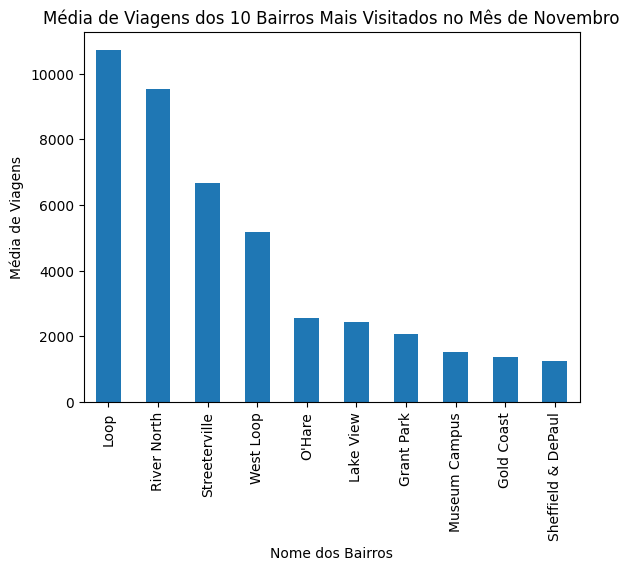

In [43]:
# Visualizando gráfico de barras para os 10 bairros mais visitados em média:
top_neighbourhoods.plot(x='dropoff_location_name', y='average_trips', kind='bar')
plt.xlabel('Nome dos Bairros')
plt.ylabel('Média de Viagens')
plt.legend('', frameon=False)
plt.title('Média de Viagens dos 10 Bairros Mais Visitados no Mês de Novembro')
plt.show()


Observações: Os bairros **Loop, River North, StreetVille** e **WestLoop** se destacam entre os 10 bairros mais escolhidos como destino, sendo **Loop** o bairro mais procurado entre eles.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Os 10 principais bairros de destino foram calculados!
</div>

### Número de corridas por empresa de taxi
Agora iramos visualisar o número de corridas realizadas por cada empresa de taxi. Para isso, vamso utilizar "df_trips_amount", organizar os dados em ordem decrescente de número de corridas e visualizar os dados em um gráfico.

In [37]:
# Ordendando "df_trips_amount" em ordem decrescente de número de viagens e criando um novo df contendo os 10 maiores valores.
top_companies = df_trips_amount.sort_values(by='trips_amount', ascending=False).head(10)

# Imprimindo as 10 empresas que mais realizaram viagens.
print('As 10 empresas de taxi que mais realizaram viagens são:')
top_companies


As 10 empresas de taxi que mais realizaram viagens são:


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


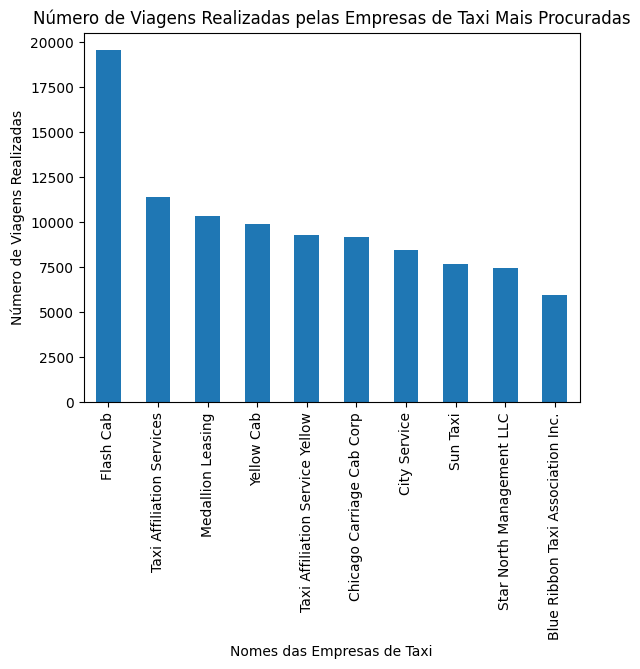

In [41]:
# Visualizando gráfico de barras para as 10 empresas de taxi que mais realizaram viagens.
top_companies.plot(x='company_name', y='trips_amount', kind='bar')
plt.xlabel('Nomes das Empresas de Taxi')
plt.ylabel('Número de Viagens Realizadas')
plt.legend('', frameon=False)
plt.title('Número de Viagens Realizadas pelas Empresas de Taxi Mais Procuradas')
plt.show()


Observações: Dentre as 10 empresas que mais realizaram viagens, a empresa **Flash Car** se destaca com o maior número de viagens realizadas. As demais empresas do ranking apresentam menor diferença entre elas em relação a número de viagens realizadas.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O número de corridas por empresa foi analisado
- Um gráfico de barras foi apresentado. Bom trabalho filtrando as principais empresas de taxi para não deixar o gráfico muito carregado!
</div>

## Viagens da Empresa Loop.
Aqui vamos analisar "df_loop_airport" contendo os dados de viagens realizadas pela empresa Loop ao Aeroporto Internacional O'Hare. Nosso objetivo é verificar se o tempo de tais viagens varia significamente de acordo com as condições climáticas em dias de sábado. Para isso, as seguintes etapas serão realizadas:
- Visializar gráfico comparando médias de tempo de viagem de acordo com a condição climática e estimar se há diferença significativa;
- Realizar teste de hipótese para verificar se o tempo das viagens tem diferença significativa de acordo com a condição climática do dia. 

### Visualizando gráfico

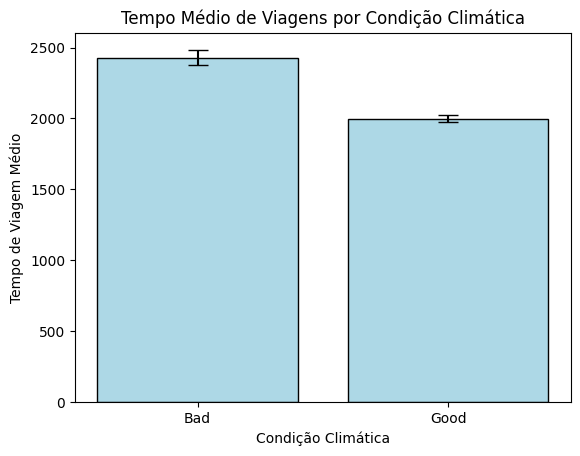

In [44]:
# Gerando novo df com dados dos sábados obtidos a partir de "df_loop_airport".
loop_stats = df_loop_airport.groupby('weather_conditions')['duration_seconds'].agg(['mean', 'sem'])

# Gerando gráfico comparativo de médias de tempo de viagem nos sábados por condição climática.
plt.bar(loop_stats.index, loop_stats['mean'], 
        yerr=loop_stats['sem'], 
        capsize=7, 
        color='lightblue', 
        edgecolor='black')
plt.title('Tempo Médio de Viagens por Condição Climática')
plt.xlabel('Condição Climática')
plt.ylabel('Tempo de Viagem Médio')
plt.show()


Observações: De acordo com gráfico comparativo, aparentemente existe diferença significativa entre o tempo de viagem de acordo com a condição climática, sendo o tempo ruim um fator que aumenta o tempo de viagem ao aeroporto. Porém, uma análise estatística é necessária para verificar se tal diferença é de fato significativa.

### Análise Estatística

Um test t de student será realizado para responder a seguinte pergunta:
- **A duração média das viagens da empresa Loop para o Aeroporto Internacional O'Hare aos sábados muda de acordo com a condição climática?**

Para responder tal pergunta, temos as seguintes hipóteses:
- **Hipótese Nula (H0)**: A duração média das viagens da empresa Loop para o Aeroporto Internacional O'Hare aos sábados é a mesma independente da condição climática;
- **Hipótese Alternativa (H1)**: A duração média das viagens da empresa Loop para o Aeroporto Internacional O'Hare aos sábados muda de acordo com a condição climática.

Para a elaboração do teste estatístico, será considerado um nível de significância de 5% (valor p = 0.05)

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Bom trabalho com a análise estatística acima!
</div>

In [52]:
# Filtrando dados para cada tipo de condição climática (Good ou Bad)
good_weather = df_loop_airport[df_loop_airport['weather_conditions'] == 'Good']['duration_seconds']
bad_weather = df_loop_airport[df_loop_airport['weather_conditions'] == 'Bad']['duration_seconds']

# Realizando Test t
result = st.ttest_ind(good_weather, bad_weather)

# Verificando resultado
alpha = 0.05

print('valor_p: ', result.pvalue)

if result.pvalue < alpha:
    print("A duração média das viagens da empresa Loop para o Aeroporto Internacional O'Hare aos sábados muda de acordo com a condição climática.")
else:
    print("A duração média das viagens da empresa Loop para o Aeroporto Internacional O'Hare aos sábados é a mesma independente da condição climática.")


valor_p:  6.517970327099473e-12
A duração média das viagens da empresa Loop para o Aeroporto Internacional O'Hare aos sábados muda de acordo com a condição climática.


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- [x] As hipóteses nula e alternativa foram definidas antes da execução do teste
- [x] Os testes foram conduzidos corretamente e o argumento `equal_var` foi configurado
- [x] O `p-value` foi calculado e exibido corretamente
- [x] O resultado foi interpretado e as conclusões foram apresentadas
</div>

Observação: O teste estatístico realizado comprovou a observação realizada através do gráfico de que as condições climáticas alteram, de maneira significativa, o tempo médio das viagens ao Aeroporto Internacional O'Hare, sendo as viagens mais longas em dias de sábado chuvosos.

## Conclusão
De acordo com as análises realisadas, é possível concluir:
- Os bairros **Loop, River North, Streeterville, West Loop, O'Hare, Lake View, Grant Park, Museum Campus** e **Gold Coast** são os 10 mais selecionados como destino no mês de novembro de 2017, sendo os 5 primeiros tendo destaque em relação aos demais e o bairro **Loop** sendo o mais procurado como destino; 
- As empresas **Flash Cab, Taxi Affiliation Services, Medallion Leasing, Yellow Cab, Taxi Affiliation Service Yellow, Chicago Carriage Cab Corp, City Service, Sun Taxi, Star North Management LLC** e **Blue Ribbon Taxi Assiciation Inc.** são as 10 empresas que mais realizaram viagens em novembro, sendo a empresa **Flash Cab** com destaque em comparação às demais com o maior número de viagens;
- O tempo de viagem de taxi feito pela empresa Loop para o Aeroporto Internacional O'Hare aos sábados muda significativamente com a condição climática, sendo dias chuvosos aqueles em que as viagens são mais longas.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

As conclusões finais foram apresentadas.
</div>